# Experiment 7.2.1 — Phase-specific vs shared L2 readout

This frozen-checkpoint extension tests whether Exp7.2 L2 activity is already phase-aware, or whether downstream classification still benefits from an explicit phase-dependent weight matrix. No SNN is retrained.

Three probes are compared: **WholeCount shared** (128-D, one time-invariant weight matrix), **ordered Fixed250** (2048-D, phase-specific weights), and **phase-shuffled Fixed250** (2048-D matched-capacity control with absolute phase identity destroyed independently per sample).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'notebooks').exists():
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_1_phase_weight_probe' / 'phase_weight_probe_v1'
architectures = pd.read_csv(ART / 'architecture_table.csv')
summary = pd.read_csv(ART / 'probe_summary.csv')
deltas = pd.read_csv(ART / 'paired_deltas.csv')
ARCH_ORDER = architectures['architecture'].tolist()
SOURCE_ORDER = ['l2_wholecount_shared', 'l2_fixed250_phase_shuffled', 'l2_fixed250_ordered']
summary.shape, deltas.shape


((252, 12), (252, 8))

## Primary test balanced accuracy

`l2_wholecount_shared` implements one shared temporal classifier because $W\sum_b z_b = \sum_b Wz_b$. `l2_fixed250_ordered` allows a distinct effective $W_b$ for each absolute 250-ms bin. The shuffled control keeps the same 2048-D capacity as ordered Fixed250 while destroying consistent phase labels.

In [2]:
test_ba = summary[(summary['split'] == 'test')].copy()
table = test_ba.pivot_table(
    index='architecture',
    columns=['training_family', 'regularization', 'source'],
    values='balanced_accuracy_mean',
).reindex(ARCH_ORDER)
display((100 * table).round(2))


training_family              e2e_wc                             \
regularization            task_only                              
source          l2_fixed250_ordered l2_fixed250_phase_shuffled   
architecture                                                     
234x234                       60.93                      39.62   
34x234                        56.08                      36.58   
34x34                         54.78                      38.23   
34x345                        54.43                      36.21   
34x45                         53.15                      35.60   
4x4                           51.84                      34.06   
5x5                           37.86                      26.04   

training_family                                           \
regularization                             task_plus_reg   
source          l2_wholecount_shared l2_fixed250_ordered   
architecture                                               
234x234                        57.37               59.89   
34x234                         53.71               58.50   
34x34                          51.86               56.98   
34x345                         49.44               51.03   
34x45                          45.26               51.76   
4x4                            46.79               49.93   
5x5                            36.10               38.61   

training_family                                                  \
regularization                                                    
source          l2_fixed250_phase_shuffled l2_wholecount_shared   
architecture                                                      
234x234                              43.27                51.42   
34x234                               41.77                56.56   
34x34                                39.03                53.09   
34x345                               33.85                45.77   
34x45                                38.22                44.66   
4x4                                  34.32                42.93   
5x5                                  25.94                33.58   

training_family          local_tsce                             \
regularization            task_only                              
source          l2_fixed250_ordered l2_fixed250_phase_shuffled   
architecture                                                     
234x234                       59.12                      47.21   
34x234                        60.37                      47.78   
34x34                         60.18                      44.75   
34x345                        57.66                      45.58   
34x45                         53.12                      43.67   
4x4                           53.75                      42.96   
5x5                           41.79                      34.79   

training_family                                           \
regularization                             task_plus_reg   
source          l2_wholecount_shared l2_fixed250_ordered   
architecture                                               
234x234                        59.54               58.97   
34x234                         60.27               63.77   
34x34                          57.29               59.65   
34x345                         56.61               61.61   
34x45                          55.47               55.28   
4x4                            51.87               55.65   
5x5                            42.76               45.07   

training_family                                                  
regularization                                                   
source          l2_fixed250_phase_shuffled l2_wholecount_shared  
architecture                                                     
234x234                              47.98                56.56  
34x234                               46.13                62.56  
34x34                                48.40                57.01  
34x345                  

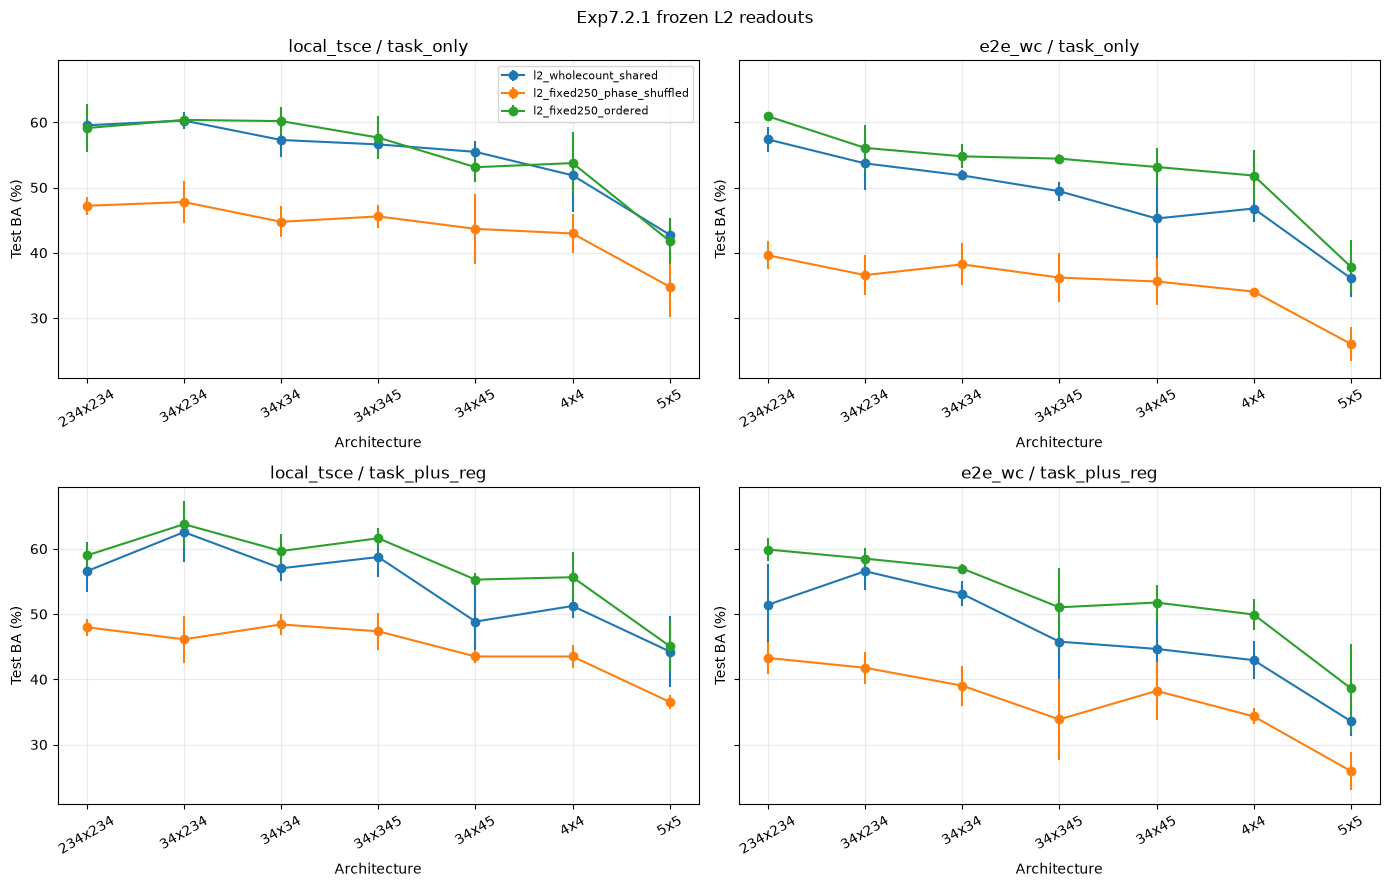

In [3]:
families = ['local_tsce', 'e2e_wc']
regularizations = ['task_only', 'task_plus_reg']
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, family, reg in zip(axes.ravel(), families * 2, ['task_only', 'task_only', 'task_plus_reg', 'task_plus_reg']):
    block = test_ba[(test_ba.training_family == family) & (test_ba.regularization == reg)]
    for source in SOURCE_ORDER:
        g = block[block.source == source].set_index('architecture').reindex(ARCH_ORDER)
        ax.errorbar(ARCH_ORDER, 100 * g['balanced_accuracy_mean'], yerr=100 * g['balanced_accuracy_std'], marker='o', label=source)
    ax.set_title(f'{family} / {reg}')
    ax.set_xlabel('Architecture')
    ax.set_ylabel('Test BA (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Exp7.2.1 frozen L2 readouts')
fig.tight_layout()


## Paired attribution

The two primary contrasts are:

- **ordered − wholecount**: benefit of allowing phase-specific weights instead of one shared temporal weight matrix.
- **ordered − phase-shuffled**: benefit of consistent absolute phase alignment at matched 2048-D feature capacity.

If both are positive, the cleanest interpretation is that useful phase information remains external to L2 and must still modulate the downstream evidence weighting.

In [4]:
ba_delta = deltas[deltas['metric'] == 'balanced_accuracy'].copy()
primary = ba_delta[ba_delta['contrast'].isin(['ordered_minus_wholecount', 'ordered_minus_phase_shuffled'])]
delta_table = primary.pivot_table(
    index='architecture',
    columns=['training_family', 'regularization', 'contrast'],
    values='delta_mean',
).reindex(ARCH_ORDER)
display((100 * delta_table).round(2))


training_family                       e2e_wc                           \
regularization                     task_only                            
contrast        ordered_minus_phase_shuffled ordered_minus_wholecount   
architecture                                                            
234x234                                21.30                     3.55   
34x234                                 19.49                     2.37   
34x34                                  16.56                     2.92   
34x345                                 18.22                     4.99   
34x45                                  17.55                     7.89   
4x4                                    17.78                     5.05   
5x5                                    11.83                     1.76   

training_family                                                        \
regularization                 task_plus_reg                            
contrast        ordered_minus_phase_shuffled ordered_minus_wholecount   
architecture                                                            
234x234                                16.62                     8.47   
34x234                                 16.73                     1.93   
34x34                                  17.95                     3.89   
34x345                                 17.18                     5.27   
34x45                                  13.54                     7.10   
4x4                                    15.60                     7.00   
5x5                                    12.67                     5.04   

training_family                   local_tsce                           \
regularization                     task_only                            
contrast        ordered_minus_phase_shuffled ordered_minus_wholecount   
architecture                                                            
234x234                                11.92                    -0.42   
34x234                                 12.59                     0.10   
34x34                                  15.43                     2.89   
34x345                                 12.08                     1.05   
34x45                                   9.45                    -2.35   
4x4                                    10.79                     1.87   
5x5                                     7.00                    -0.97   

training_family                                                        
regularization                 task_plus_reg                           
contrast        ordered_minus_phase_shuffled ordered_minus_wholecount  
architecture                                                           
234x234                                10.99                     2.41  
34x234                                 17.64                     1.21  
34x34                                  11.25                     2.64  
34x345                                 14.26                     2.88  
34x45                                  11.78                     6.43  
4x4                                    12.15                     4.41  
5x5                                     8.55                     0.82

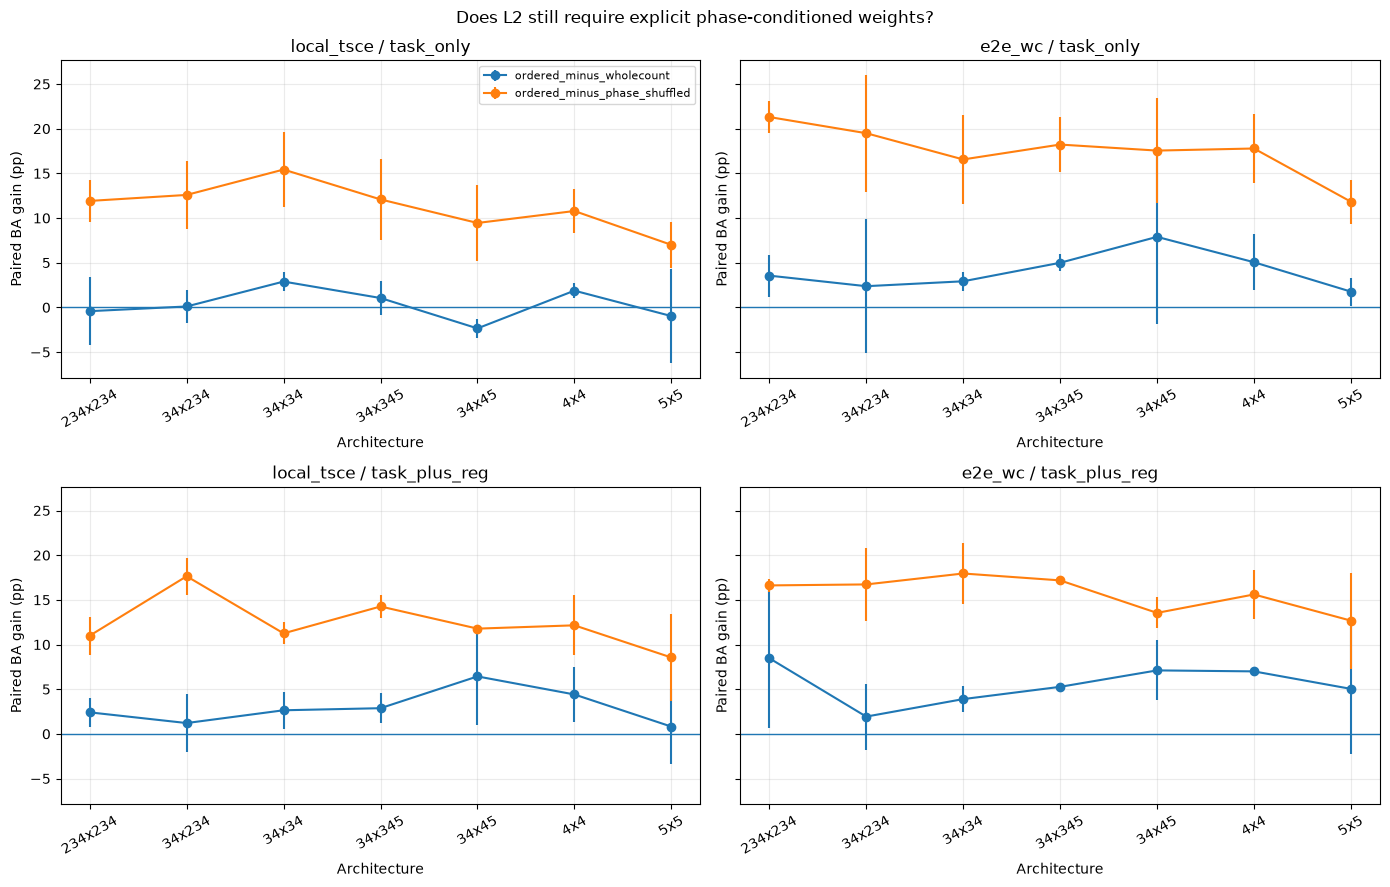

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, family, reg in zip(axes.ravel(), families * 2, ['task_only', 'task_only', 'task_plus_reg', 'task_plus_reg']):
    block = primary[(primary.training_family == family) & (primary.regularization == reg)]
    for contrast in ['ordered_minus_wholecount', 'ordered_minus_phase_shuffled']:
        g = block[block.contrast == contrast].set_index('architecture').reindex(ARCH_ORDER)
        ax.errorbar(ARCH_ORDER, 100 * g['delta_mean'], yerr=100 * g['delta_std'], marker='o', label=contrast)
    ax.axhline(0, linewidth=1)
    ax.set_title(f'{family} / {reg}')
    ax.set_xlabel('Architecture')
    ax.set_ylabel('Paired BA gain (pp)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Does L2 still require explicit phase-conditioned weights?')
fig.tight_layout()


In [6]:
ranked = primary.sort_values('delta_mean', ascending=False)[
    ['contrast', 'architecture', 'training_family', 'regularization', 'delta_mean', 'delta_std', 'n']
].copy()
ranked['delta_mean_pp'] = 100 * ranked['delta_mean']
ranked['delta_std_pp'] = 100 * ranked['delta_std']
display(ranked.drop(columns=['delta_mean', 'delta_std']).head(30).round(2))


,contrast,architecture,training_family,regularization,n,delta_mean_pp,delta_std_pp
1,ordered_minus_phase_shuffled,234x234,e2e_wc,task_only,3,21.30,1.83
13,ordered_minus_phase_shuffled,34x234,e2e_wc,task_only,3,19.49,6.54
37,ordered_minus_phase_shuffled,34x345,e2e_wc,task_only,3,18.22,3.11
28,ordered_minus_phase_shuffled,34x34,e2e_wc,task_plus_reg,3,17.95,3.38
61,ordered_minus_phase_shuffled,4x4,e2e_wc,task_only,3,17.78,3.88
22,ordered_minus_phase_shuffled,34x234,local_tsce,task_plus_reg,3,17.64,2.08
49,ordered_minus_phase_shuffled,34x45,e2e_wc,task_only,3,17.55,5.88
40,ordered_minus_phase_shuffled,34x345,e2e_wc,task_plus_reg,3,17.18,0.26
16,ordered_minus_phase_shuffled,34x234,e2e_wc,task_plus_reg,3,16.73,4.05
4,ordered_minus_phase_shuffled,234x234,e2e_wc,task_plus_reg,3,16.62,0.68
